In [339]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import node2vec
import networkx as nx

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import HDBSCAN
import umap

ModuleNotFoundError: No module named 'node2vec'

In [343]:
!pip3 install node2vec

  Using cached node2vec-0.5.0-py3-none-any.whl.metadata (849 bytes)
  Using cached gensim-4.4.0.tar.gz (23.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached numpy-1.26.4-cp314-cp314-macosx_15_0_arm64.whl
  Using cached smart_open-7.6.1-py3-none-any.whl.metadata (25 kB)
  Using cached wrapt-2.2.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (7.4 kB)
Using cached node2vec-0.5.0-py3-none-any.whl (7.2 kB)
Using cached smart_open-7.6.1-py3-none-any.whl (64 kB)
Using cached wrapt-2.2.1-cp314-cp314-macosx_11_0_arm64.whl (81 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for gensim (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [797 lines of output]
      /private/var/folders/6d/q_rjz0td26lc9b61yr0prhxm0000gp/T/pip-build-env-_bo79wqn/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.py:287: UserWarning: Unknown distribution option: 'test_suit

In [2]:
GOLD = "gdo168.llnl.gov/data/ACME4/gold"

In [3]:
# Load the gold train/test splits (one row per process execution).
df_train = pd.read_parquet(f"{GOLD}/train-process_uber_summary.parquet")
df_test  = pd.read_parquet(f"{GOLD}/test-process_uber_summary.parquet")

df_acme = df_train
df_acme.head(5)

,pid_hash,os_family,agent_id,num_agent_id,hostname,os_pid,process_name,num_process_name,args,num_args,...,lolbas_mitre,lolc_class,lolbas_num_rows,mitre_analytic_ids,mitre_information_domains,mitre_subtypes,mitre_analytic_types,mitre_num_rows,bad_user,red_team
0,CF830E1523374BE7F0E5F91F7936443E,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,1900,wmic.exe,1,os get version /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
1,42DEC9F24F7D08578FB30A75AF68C661,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-DXJ,3748,wmic.exe,1,computersystem get dnshostname /value,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
2,A4207647384708DBA1C4552112C948F9,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,5268,wmic.exe,1,os get version /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
3,D7D35ACED1E249E503B9049D2F9599BD,windows,baa6d56b-daab-414f-bfd5-4ffafb247689,1,ACME-HH-CWQ,3056,wmic.exe,1,computersystem get domain /value,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0
4,224B925BA2818C792E07DE5FFD088CCC,windows,f9ac46c8-0959-4bce-82d9-556a971e7f1a,1,ACME-WS-PLU,5160,wmic.exe,1,os get caption /format:list,1,...,"[T1218, T1564.004]",NEUTRAL,1.0,[CAR-2021-05-012],[Analytic],[[Process]],[[TTP]],1.0,None,0


Graph Construction

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

Graph = nx.Graph()

Graph.add_node(124, process_name="cmd.exe", user="alice")

Graph.add_node(13, process_name="cmd.exe", user="Bob")

Graph.add_node(33, process_name="cmd.exe", user="Bob")

Graph.add_edge(124, 13, weight=0.5)
Graph.add_edge(124, 33, weight=0.5)
Graph.add_edge(13, 33, weight=0.5)

[(124, {'process_name': 'cmd.exe', 'user': 'alice'}), (13, {'process_name': 'cmd.exe', 'user': 'Bob'}), (33, {'process_name': 'cmd.exe', 'user': 'Bob'})]


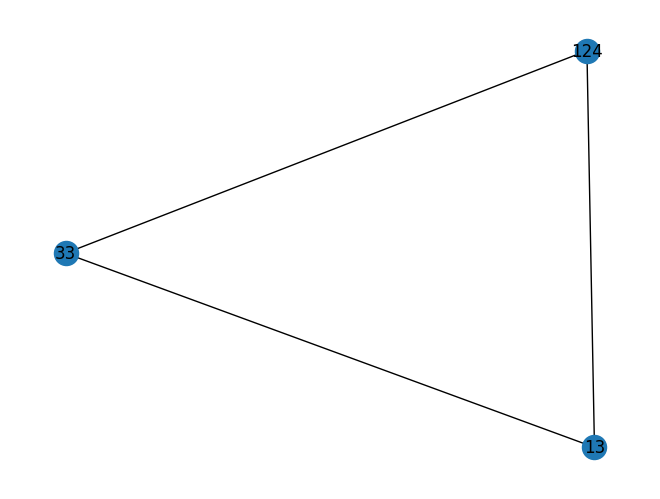

In [5]:
print(Graph.nodes(data=True))

nx.draw(Graph, with_labels=True)
plt.show()

In [44]:

nx.write_gexf(Graph, "my_graph.gexf")

Create GraphBuilder class that takes in a dataframe and constructs a graph based on process execution patterns, shared artifacts, temporal proximity, etc. 

Use LLM-assisted edge type extraction to identify important features for graph construction.

In [321]:
class GraphBuilder:
    """
    Create a graph from the passed dataframe and embed it using a graph embedding technique (e.g., node2vec, GCN, etc.).
    Each node in the graph represents a process execution, and edges represent relationships between processes (e.g., parent-child relationship, shared artifact touched, etc.).
    """

    def __init__(self):
        # Initialize class variables, e.g., graph, node/edge feature dictionaries, etc.
        self.sessions = [] # List to store graph sessions (e.g., list of node IDs for each session)
        self.graph = nx.Graph() # Initialize an empty graph using a graph library (e.g., NetworkX, DGL, PyTorch Geometric, etc.)

    def build_graph(self, df, llm_edge_type_extraction=False):
        """Build the graph from the passed dataframe."""
        print(f"Building graph...")
        self.add_process_node(df)
        self.add_parent_child_edge(df)
        self.add_rare_artifact_touched_edge(df)
        self.add_same_user_edge(df)

        # User can optionally enable LLM-assisted edge type extraction to identify 
        # additional edge types for graph construction.
        if llm_edge_type_extraction:
            self.add_llm_assisted_edge_type_extraction(df)

        # Extract sesions after graph construction
        self.extract_sessions()

        return self.graph

    def add_llm_assisted_edge_type_extraction(self, df, description=""):
        """Use LLM-assisted edge type extraction to identify important features for graph construction."""
        print(f"Using LLM-assisted edge type extraction... following this description: {description}")
        pass

    def add_process_node(self, df):
        """Add a node for each process execution in the passed dataframe. (Data)"""
        print(f"Adding process nodes...")

        for idx, row in df.iterrows():
            self.graph.add_node(
                row["pid_hash"], # Unique id for this node (process execution)
                
                # Core Process Attributes 
                process_name = row["process_name"] if pd.notna(row["process_name"]) else "N/A",
                hostname = row["hostname"] if pd.notna(row["hostname"]) else "N/A",
                user_name = row["user_name"] if pd.notna(row["user_name"]) else "N/A",

                # Temporal Attributes
                process_started = str(row["process_started"]) if pd.notna(row["process_started"]) else "N/A",
                duration_seconds = float(row["duration_seconds"]) if pd.notna(row["duration_seconds"]) else 0,

                # Parent-child relationship
                parent_pid_hash = row["parent_pid_hash"] if pd.notna(row["parent_pid_hash"]) else "N/A",
                
                # For future embedding (behavioural signals)
                num_file_hash = int(row["num_uniq_file_hash"]) if pd.notna(row["num_uniq_file_hash"]) else 0,
                net_total_events = int(row["net_total_events"]) if pd.notna(row["net_total_events"]) else 0,
                conn_id_count = int(row["conn_id_count"]) if pd.notna(row["conn_id_count"]) else 0,
                reg_totals = int(row["reg_totals"]) if pd.notna(row["reg_totals"]) else 0,

                labels = int(row["red_team"]) if pd.notna(row["red_team"]) else 0
            )

    def add_parent_child_edge(self, df):
        """This edge type connects a parent process to its child process."""
        print(f"Adding parent-child edges...")

        for idx, row in df.iterrows():
            if pd.notna(row["parent_pid_hash"]):
                parent_id = row["parent_pid_hash"]
                child_id = row["pid_hash"]

                if self.graph.has_node(parent_id) and self.graph.has_node(child_id):
                    self.graph.add_edge(parent_id, child_id, edge_type="parent_child")
        

    def add_rare_artifact_touched_edge(self, df):
        """Connect processes touching the same rare artifact."""
        print("Adding rare artifact edges...")
        
        # Step 1: Calculate file frequency across ALL rows
        file_counts = df['filename'].value_counts()
        
        # Step 2: Define "rare" (e.g., appears in < 1% of processes)
        threshold = len(df) * 0.01
        rare_files = file_counts[file_counts < threshold].index
        
        # Step 3: For each rare file, connect all processes that touched it
        for rare_file in rare_files:
            processes_touching_file = df[df['filename'] == rare_file]['pid_hash'].tolist()
            
            # Connect all pairs that touched this rare file
            for i in range(len(processes_touching_file)):
                for j in range(i+1, len(processes_touching_file)):
                    self.graph.add_edge(
                        processes_touching_file[i],
                        processes_touching_file[j],
                        edge_type='rare_artifact',
                        artifact=rare_file
                    )

    def add_same_user_edge(self, df):
        """Connect processes executed by the same user."""
        print("Adding same user edges...")

        for (user, host), group in df.groupby(["user_name", "hostname"]):
            if pd.isna(user) or pd.isna(host):
                continue

            group = group.sort_values("process_started")
            pid_hashes = group["pid_hash"].tolist()

            time_window = pd.Timedelta(hours=1)

            for i in range(len(pid_hashes)):
                for j in range(i+1, len(pid_hashes)):
                    time_diff = group.iloc[j]["process_started"] - group.iloc[i]["process_started"]

                    if time_diff <= time_window:
                        if self.graph.has_node(pid_hashes[i]) and self.graph.has_node(pid_hashes[j]):
                            self.graph.add_edge(
                                pid_hashes[i],
                                pid_hashes[j],
                                edge_type="same_user",
                                user=user,
                                host=host
                            )
                    
                    else:
                        break


    def embed_graph(self):
        """Embed the graph using a graph embedding technique (e.g., node2vec, GCN, etc.)."""
        print(f"Embedding {len(self.sessions)} sessions...")

        session_embeddings = []
        session_labels = []

        for session in self.sessions:
            # Numerical features (aggregate with mean)
            node_features = []

            # Categorical Features (aggregate with counts)
            process_names = []
            hostnames = []
            usernames = []

            for node_id in session:
                node = self.graph.nodes[node_id]
                features = [
                    node.get("duration_seconds", 0),
                    node.get("num_file_hash", 0),
                    node.get("net_total_events", 0),
                    node.get("conn_id_count", 0),
                    node.get("reg_totals", 0)
                ]
                node_features.append(features)

                # Collect categorical features
                process_names.append(node.get("process_name", "N/A"))
                hostnames.append(node.get("hostname", "N/A"))
                usernames.append(node.get("user_name", "N/A"))

            # Aggregate numerical features (mean pooling)
            numerical_embed = np.mean(node_features, axis=0)

            # Aggregate categorical features (count of unique values)
            categorical_embed = [
                len(set(process_names)), # Number of unique process names in this session
                len(set(hostnames)),     # Number of unique hostnames in this session
                len(set(usernames)),     # Number of unique usernames in this session
                len(session)             # Number of nodes in this session
            ]

            # Combine both
            session_embed = np.concatenate([numerical_embed, categorical_embed])
            session_embeddings.append(session_embed)

            # Label: any red_team occurance means malicious session
            has_malicious = any(self.graph.nodes[n].get("malicious") == 1 for n in session)
            session_labels.append(has_malicious)

        return np.array(session_embeddings), np.array(session_labels)
    
    
    def extract_sessions(self):
            """Extract sessions from the graph. A session is defined as a connected component in the graph."""
            print(f"Extracting sessions from graph with {self.graph.number_of_nodes()} nodes and {self.graph.number_of_edges()} edges...")
            self.sessions = [list(component) for component in nx.connected_components(self.graph)]
            print(f"Extracted {len(self.sessions)} sessions.")

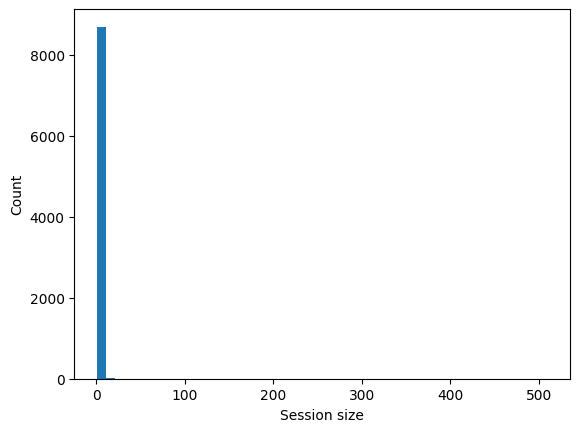

In [322]:
sizes = [len(s) for s in sessions]
plt.hist(sizes, bins=50)
plt.xlabel("Session size")
plt.ylabel("Count")
plt.show()

In [323]:
# for x in df_acme.columns:
    # print(x)

# df_acme

In [337]:
builder = GraphBuilder()

graph = builder.build_graph(df_acme.head(20000), llm_edge_type_extraction=True)

embeddings, labels = builder.embed_graph()
print(f"Embeddings shape: {embeddings.shape}")
print(f"Labels shape: {labels.shape}")
# builder.add_llm_assisted_edge_type_extraction(df_acme.head(250), description="Identify additional edge types for graph construction based on process execution patterns, shared artifacts, temporal proximity, etc.")

Building graph...
Adding process nodes...
Adding parent-child edges...
Adding rare artifact edges...
Adding same user edges...
Using LLM-assisted edge type extraction... following this description: 
Extracting sessions from graph with 20000 nodes and 60014 edges...
Extracted 17339 sessions.
Embedding 17339 sessions...
Embeddings shape: (17339, 9)
Labels shape: (17339,)


In [338]:
embeddings

array([[36.06 ,  2.   ,  0.   , ...,  1.   ,  1.   ,  1.   ],
       [22.054,  2.   ,  0.   , ...,  1.   ,  1.   ,  1.   ],
       [12.567,  2.   ,  0.   , ...,  1.   ,  1.   ,  1.   ],
       ...,
       [23.076,  0.   ,  0.   , ...,  1.   ,  1.   ,  1.   ],
       [33.837,  0.   ,  0.   , ...,  1.   ,  1.   ,  1.   ],
       [ 0.5  ,  0.   ,  0.   , ...,  1.   ,  1.   ,  1.   ]],
      shape=(17339, 9))

In [336]:
for l in labels:
    print(f"Label: {l}")
    if l == True:
        print("Malicious session detected!")

Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False
Label: False

Visualize Distribution

In [310]:
print(f"Nodes: {graph.number_of_nodes()}")
print(f"Edges: {graph.number_of_edges()}")
print(f"Connected components: {nx.number_connected_components(graph)}")

Nodes: 10000
Edges: 13362
Connected components: 8703


In [311]:
# Add detailed diagnostics:
print(f"Total sessions: {len(sessions)}")
print(f"Singleton sessions: {sum(1 for s in sessions if len(s) == 1)}")
print(f"Sessions with 2+ nodes: {sum(1 for s in sessions if len(s) > 1)}")
print(f"Largest session: {max(len(s) for s in sessions)}")

# Check edge type distribution
edge_types = [graph.edges[e].get('edge_type', 'unknown') for e in graph.edges()]
from collections import Counter
print("\nEdge type counts:")
for et, count in Counter(edge_types).items():
    print(f"  {et}: {count}")

# Check why parent-child edges are failing
df_sample = df_acme.head(10000)
print(f"\nRows with parent_pid_hash: {df_sample['parent_pid_hash'].notna().sum()}")
print(f"Unique parent PIDs in nodes: {sum(1 for n in graph.nodes() if graph.nodes[n]['parent_pid_hash'] != 'N/A')}")

Total sessions: 9014
Singleton sessions: 8870
Sessions with 2+ nodes: 144
Largest session: 383

Edge type counts:
  same_user: 2239
  rare_artifact: 11121
  parent_child: 2

Rows with parent_pid_hash: 10000
Unique parent PIDs in nodes: 10000


Extract sessions:

In [312]:
sessions = list(nx.connected_components(graph))
print(f"Session sizes: {[len(s) for s in sessions[:10]]}")

Session sizes: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


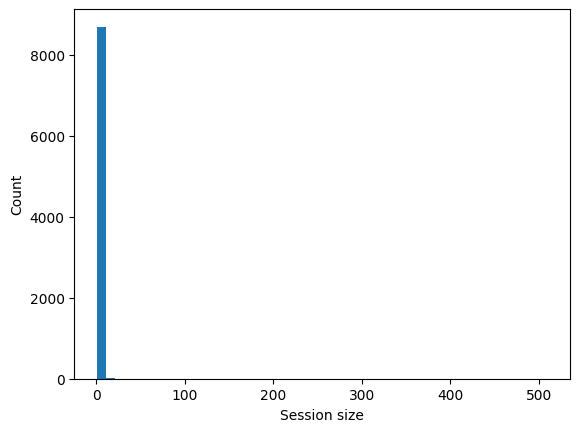

In [313]:
sizes = [len(s) for s in sessions]
plt.hist(sizes, bins=50)
plt.xlabel("Session size")
plt.ylabel("Count")
plt.show()

In [314]:
from pyvis.network import Network

net = Network(notebook=True, cdn_resources="remote")
net.from_nx(graph)
net.show("graph.html")

graph.html


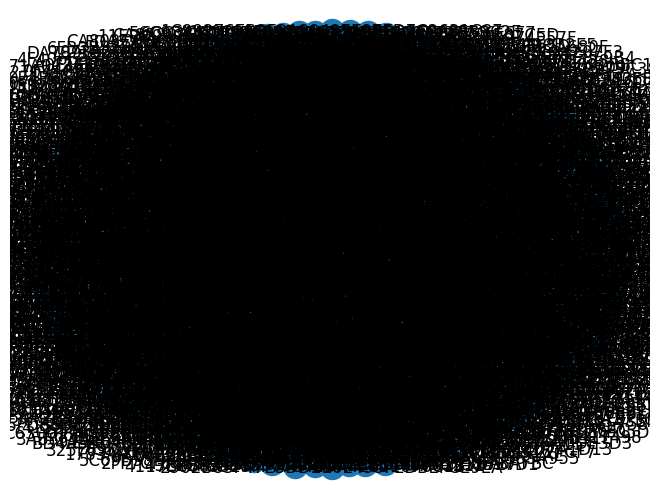

In [274]:
# graph.nodes(data=True)
nx.draw(graph, with_labels=True)
plt.show()

In [260]:
nx.write_gexf(graph, "my_graph.gexf")